In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shohinurpervezshohan/global-sales-performance-dataset")

print("Path to dataset files:", path)

100%|██████████| 20.8k/20.8k [00:00<00:00, 726kB/s]

Extracting files...
Path to dataset files: C:\Users\ZXT3080\.cache\kagglehub\datasets\shohinurpervezshohan\global-sales-performance-dataset\versions\1


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# load data
df = pd.read_csv('../../data/Global_Sales_data.csv')
df.head()

,Region,Salesperson,Revenue,Profit,Units_Sold,Customer_Satisfaction,Marketing_Spend,Discount_Percentage,Product_Category,Sales_Channel,Order_Processing_Time
0,East,Alice,137118,10067,219,4.06,14666,13.40,Furniture,Retail,1
1,West,Alice,78577,38481,750,2.64,8254,3.70,Automobile,Wholesale,3
2,North,Alice,19078,28037,406,3.62,14746,6.18,Furniture,Retail,3
3,East,Eve,166075,10557,109,2.04,4578,0.03,Furniture,Online,5
4,East,David,72768,10435,40,1.64,13353,1.18,Electronics,Wholesale,3


### 🚫 Visualization Example  #1  
##### “Rainbow Chaos Profit Scatter”

---

### 🎯 Intended Purpose (Supposedly)

> Show **Profit vs Revenue by Region**

---

##### Please review the visualization below. 

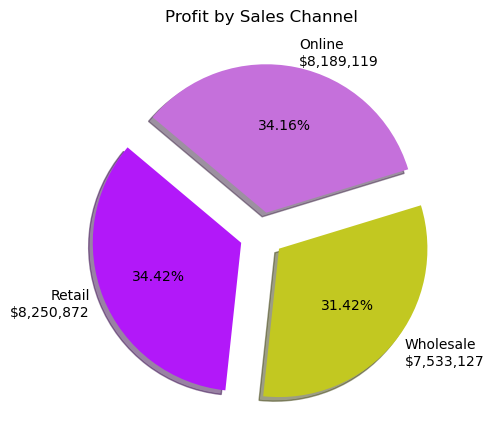

In [4]:
### To visual the Profit by Sales Channels

# Aggregate profit by sales channel
profit_by_channel = df.groupby("Sales_Channel")["Profit"].sum()

# INTENTIONALLY BAD: pie charts can't handle negative values well,
# so we take absolute value (this is misleading and is part of the "bad example")
profit_abs = profit_by_channel.abs()

# Random colors (intentionally bad)
rng = np.random.default_rng(42)
colors = rng.random((len(profit_abs), 3))

# Explode everything (intentionally bad)
explode = [0.15] * len(profit_abs)

plt.figure(figsize=(5, 5))
plt.pie(
    profit_abs,
    labels=[f"{ch}\n${v:,.0f}" for ch, v in profit_by_channel.items()],  # crowded labels
    autopct="%1.2f%%",  # unnecessary precision
    startangle=17,      # arbitrary
    colors=colors,
    explode=explode,
    shadow=True         # extra decoration
)

plt.title("Profit by Sales Channel", pad=20)
plt.tight_layout()
plt.show()

### Please analyze the visualization above using the concepts discussed and evaluate whether it aligns with or violates the Gestalt principles and preattentive attributes. Support your discussion with specific examples from the visual.

1. Uses a pie chart
2. Applies random rainbow colors
3. Explodes every slice 
4. Uses absolute profit to “make the pie work”
5. Uses percentage labels
6. White out background
7. No legend but labels in-position

### 🚫 Visualization Excample #2
“Overloaded Pie Dashboard”
Purpose (supposedly)

### Show Revenue by Product Category and Region.



| Problem                  | Why It’s Bad                   |
| ------------------------ | ------------------------------ |
| Pie chart for comparison | Angle perception weak          |
| Too many slices          | Violates perceptual grouping   |
| Bright saturated colors  | No figure–ground               |
| No proximity grouping    | Regions not visually clustered |
| No hierarchy             | Everything competes            |


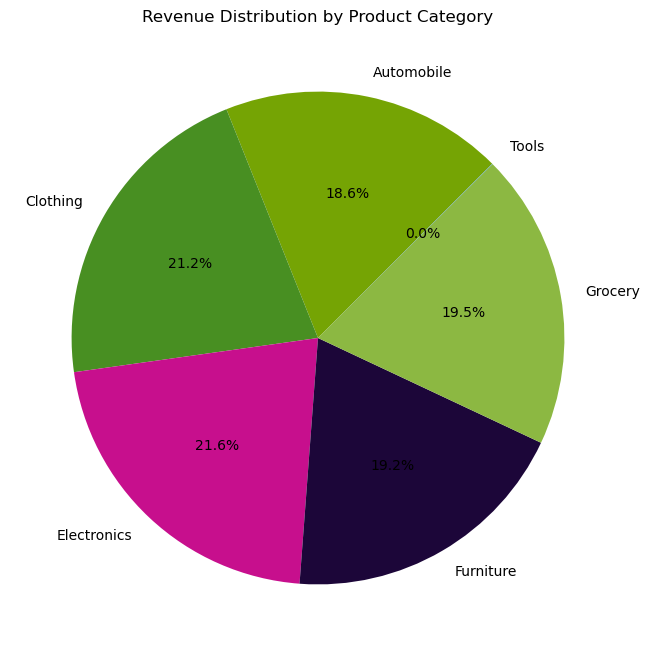

In [5]:
# load 
df = pd.read_csv("../../data/Global_Sales_Data_With_Tools_Category.csv")

# Aggregate revenue by product category
rev_cat = df.groupby("Product_Category")["Revenue"].sum()

# Random bright colors
colors = np.random.rand(len(rev_cat), 3)

plt.figure(figsize=(8,8))

plt.pie(
    rev_cat,
    labels=rev_cat.index,
    colors=colors,
    autopct='%1.1f%%',
    startangle=45
)

plt.title("Revenue Distribution by Product Category")

plt.show()